55398 23742 (55398, 10) (23742, 10)
55398 23742
            MaxTemp       MinTemp       Temp9am       Temp3pm   Pressure3pm  \
count  55398.000000  55398.000000  55398.000000  55398.000000  55398.000000   
mean      23.632528     12.626672     17.427364     22.106719   1015.091287   
std        6.964157      6.223687      6.340894      6.814940      6.976438   
min        2.600000     -7.000000     -3.100000      2.300000    978.200000   
25%       18.200000      8.100000     12.700000     16.900000   1010.400000   
50%       23.100000     12.400000     17.000000     21.600000   1015.100000   
75%       28.600000     17.200000     22.000000     26.800000   1019.800000   
max       48.100000     33.900000     40.200000     46.700000   1039.600000   

        Pressure9am  WindGustSpeed  WindSpeed3pm  WindSpeed9am     RainToday  
count  55398.000000   55398.000000  55398.000000  55398.000000  55398.000000  
mean    1017.471504      40.747680     19.492274     15.175421      0.356890  
std

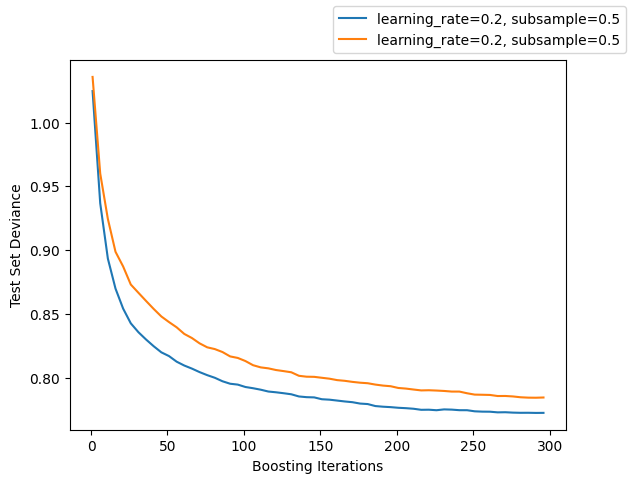

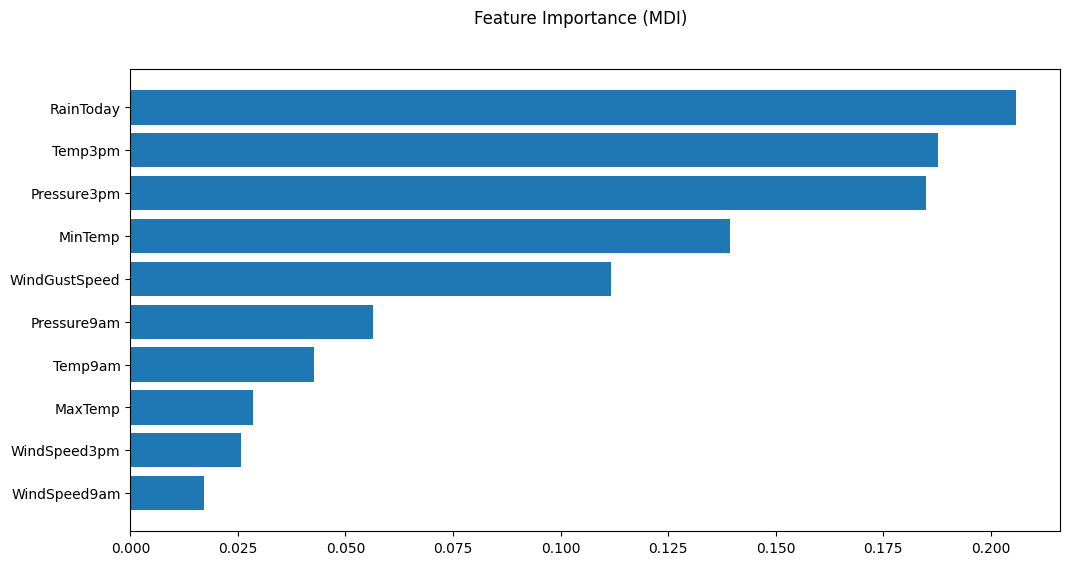

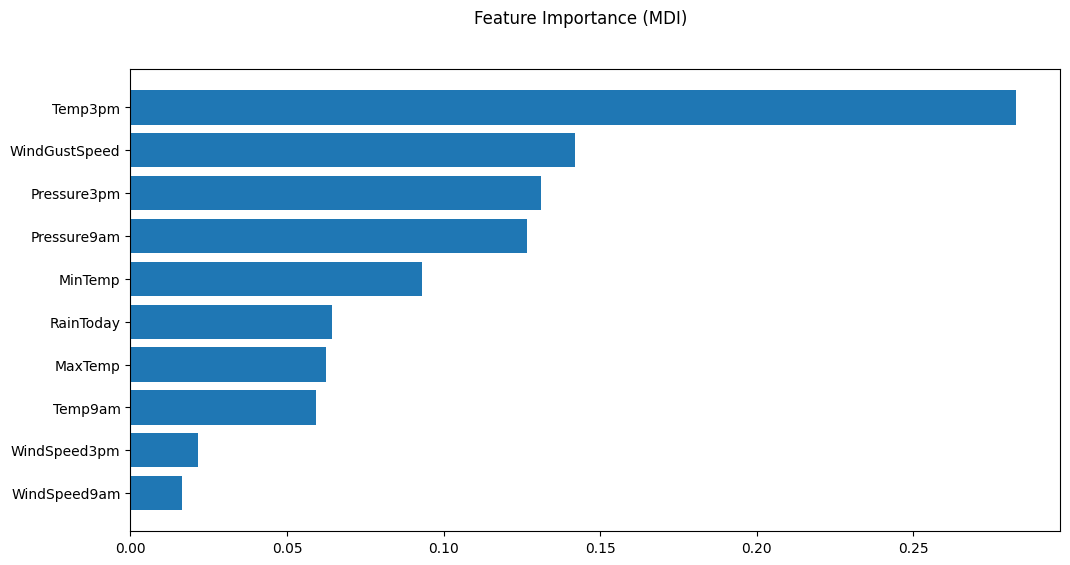

In [ ]:
import dataclasses
from typing import Dict, List

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from src.downstream_task.config import RegressionConfig
from src.utils import get_raw_results, res_raw
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

from sklearn import ensemble
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split


config = RegressionConfig(
    max_leaf_nodes=4,
    min_samples_split=5,
    test_size=0.3,
    n_estimators=300,
    max_depth=None,
    subsample=0.5,
    learning_rate=0.2,
)

cleaned_data, polluted_data, polluted_dq, polluted_certainty = prepare_data(config)


# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regression.html
def plot_feature_importance(clf: ensemble.GradientBoostingClassifier, feature_names):
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(pos, feature_importance[sorted_idx], align="center")
    ax.set_yticks(pos, feature_names[sorted_idx])
    fig.suptitle("Feature Importance (MDI)")
    return fig


results = {}


# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regularization.html#sphx-glr-auto-examples-ensemble-plot-gradient-boosting-regularization-py

X_c, y_c = cleaned_data.drop("RainTomorrow", axis=1), cleaned_data["RainTomorrow"]
X_p, y_p = polluted_data.drop("RainTomorrow", axis=1), polluted_data["RainTomorrow"]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c,
    y_c,
    test_size=config.test_size,
    random_state=config.random_state,
)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p,
    y_p,
    test_size=config.test_size,
    random_state=config.random_state,
)

original_params: Dict[str, float | None] = {
    "n_estimators": 300,
    "max_leaf_nodes": 4,
    "max_depth": None,
    "random_state": 2,
    "min_samples_split": 5,
}

loss_fig, loss_fig_ax = plt.subplots()

for label, color, setting in [
    # ("No shrinkage", "orange", {"learning_rate": 1.0, "subsample": 1.0}),
    # ("learning_rate=0.2", "turquoise", {"learning_rate": 0.2, "subsample": 1.0}),
    # ("subsample=0.5", "blue", {"learning_rate": 1.0, "subsample": 0.5}),
    (
        "learning_rate=0.2, subsample=0.5",
        "gray",
        {"learning_rate": 0.2, "subsample": 0.5},
    ),
    # (
    #     "learning_rate=0.2, max_features=2",
    #     "magenta",
    #     {"learning_rate": 0.2, "max_features": 2},
    # ),
]:
    for X_train, y_train, X_test, y_test in [
        (X_c_train, y_c_train, X_c_test, y_c_test),
        (X_p_train, y_p_train, X_c_test, y_c_test),
    ]:
        scaler = StandardScaler()
        scaler.fit(X_train)

        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        params = dict(original_params)
        params.update(setting)

        clf = ensemble.GradientBoostingClassifier(**params)  # type: ignore
        clf.fit(X_train_scaled, y_train)

        # compute test set deviance
        test_deviance = np.zeros((params["n_estimators"],), dtype=np.float64)

        for i, y_proba in enumerate(clf.staged_predict_proba(X_test_scaled)):
            test_deviance[i] = 2 * log_loss(y_test, y_proba[:, 1])

        loss_fig_ax.plot(
            (np.arange(test_deviance.shape[0]) + 1)[::5],
            test_deviance[::5],
            "-",
            label=label,
        )
        plot_feature_importance(clf, X_c.columns)

    loss_fig.legend(loc="upper right")
    loss_fig_ax.set_xlabel("Boosting Iterations")
    loss_fig_ax.set_ylabel("Test Set Deviance")
None

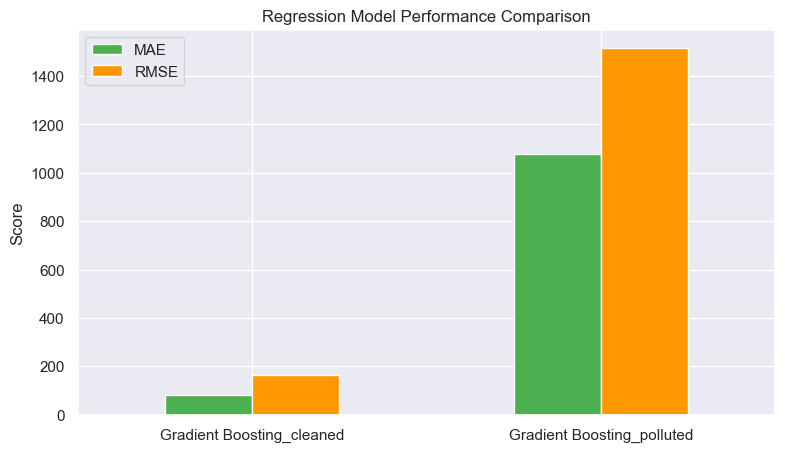

In [ ]:
import dataclasses
from typing import Dict, List

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from src.utils import get_raw_results, res_raw
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

from sklearn import ensemble
from sklearn.metrics import f1_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from src.downstream_task.config import RegressionConfig


config = RegressionConfig(
    max_leaf_nodes=4,
    min_samples_split=5,
    test_size=0.3,
    n_estimators=300,
    max_depth=None,
    subsample=0.5,
    learning_rate=0.2,
    cols=["QUANTITYORDERED", "PRICEEACH", "ORDERLINENUMBER", "SALES", "MSRP"],
)

df_raw = get_raw_results()

cleaned_results = df_raw[
    (df_raw["dataset"] == "auto_sales")
    & (df_raw["metric"] == "completeness_nullAndDMVRatio")
    & (df_raw["type"] == "cleaned")
]
polluted_results = df_raw[
    (df_raw["dataset"] == "auto_sales")
    & (df_raw["metric"] == "consistency_ruleBasedPipino")
    & (df_raw["dimension"] == "consistency_tuple")
    & (df_raw["type"] == "polluted")
    & (df_raw["pollution_mechanism"] == "ECAR")
    & (df_raw["pollution_rate"] == 0.35)
]

cleaned_data = pd.DataFrame(
    {res["column"]: res["result"].data for _, res in cleaned_results.iterrows()}
)[config.cols]

assert len(polluted_results) == 1, polluted_results

polluted_data = pd.DataFrame(
    polluted_results.iloc[0]["result"].data,
    columns="ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE".split(
        ","
    ),
)[config.cols]

polluted_dq = pd.Series(
    polluted_results.iloc[0]["result"].dq_result,
)
polluted_certainty = pd.Series(
    polluted_results.iloc[0]["result"].certainty,
)

target_column = "SALES"

X_c, y_c = cleaned_data.drop(target_column, axis=1), cleaned_data[target_column]
X_p, y_p = polluted_data.drop(target_column, axis=1), polluted_data[target_column]

cat_features = X_c.select_dtypes(include=["object"]).columns.tolist()
num_features = X_c.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
        ("num", "passthrough", num_features),
    ]
)

random_state = np.random.RandomState(config.random_seed)
models = {
    # "Linear Regression": LinearRegression(),
    "Gradient Boosting": ensemble.GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=random_state,
        max_leaf_nodes=4,
        min_samples_split=5,
    ),
}

results = {}

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c,
    y_c,
    test_size=config.test_size,
    random_state=random_state,
)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p,
    y_p,
    test_size=config.test_size,
    random_state=random_state,
)

X, y = X_c, y_c


original_params: Dict[str, float | None] = {
    "n_estimators": 300,
    "max_leaf_nodes": 4,
    "max_depth": None,
    "random_state": 2,
    "min_samples_split": 5,
}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    for (X_train, y_train, X_test, y_test), data_key in [
        ((X_c_train, y_c_train, X_c_test, y_c_test), "cleaned"),
        ((X_p_train, y_p_train, X_c_test, y_c_test), "polluted"),
    ]:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name + "_" + data_key] = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        }

results_df = pd.DataFrame(results).T

results_df.plot(kind="bar", figsize=(9, 5), color=["#4CAF50", "#FF9800", "#03A9F4"])

plt.title("Regression Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from downstream import plot_results, run_downstream_task

results_folder = run_downstream_task("weather")
plot_results(results_folder)

Loading raw results...
Completed run 1 after 26.20 seconds
Completed run 2 after 25.25 seconds
Completed run 3 after 25.72 seconds
Completed run 4 after 25.57 seconds
Completed run 5 after 24.86 seconds
Completed run 6 after 26.04 seconds
Completed run 7 after 24.88 seconds
Completed run 8 after 25.62 seconds
Completed run 9 after 26.72 seconds
Completed run 10 after 25.39 seconds
Completed run 11 after 24.87 seconds
Completed run 12 after 24.92 seconds
Completed run 13 after 24.75 seconds
Completed run 14 after 25.16 seconds
Completed run 15 after 24.88 seconds
Completed run 16 after 24.93 seconds
Completed run 17 after 25.00 seconds
Completed run 18 after 25.04 seconds
Completed run 19 after 24.92 seconds
Completed run 20 after 24.62 seconds
Completed run 21 after 24.78 seconds
Completed run 22 after 24.94 seconds
Completed run 23 after 24.70 seconds
Completed run 24 after 25.01 seconds
Completed run 25 after 24.53 seconds
Completed run 26 after 24.84 seconds
Completed run 27 after 2

In [ ]:
from downstream import plot_results, run_downstream_task

results_folder = run_downstream_task("auto_sales")
plot_results(results_folder)

Completed run 1 after 0.43 seconds
Completed run 2 after 0.42 seconds
Completed run 3 after 0.40 seconds
Completed run 4 after 0.41 seconds
Completed run 5 after 0.41 seconds
Completed run 6 after 0.42 seconds
Completed run 7 after 0.42 seconds
Completed run 8 after 0.42 seconds
Completed run 9 after 0.41 seconds
Completed run 10 after 0.42 seconds
Completed run 11 after 0.43 seconds
Completed run 12 after 0.46 seconds
Completed run 13 after 0.41 seconds
Completed run 14 after 0.40 seconds
Completed run 15 after 0.40 seconds
Completed run 16 after 0.40 seconds
Completed run 17 after 0.41 seconds
Completed run 18 after 0.41 seconds
Completed run 19 after 0.41 seconds
Completed run 20 after 0.39 seconds
Completed run 21 after 0.41 seconds
Completed run 22 after 0.40 seconds
Completed run 23 after 0.39 seconds
Completed run 24 after 0.40 seconds
Completed run 25 after 0.42 seconds
Completed run 26 after 0.41 seconds
Completed run 27 after 0.42 seconds
Completed run 28 after 0.40 seconds
C

INFO:faiss.loader:Loading faiss.
INFO:faiss.loader:Successfully loaded faiss.


Evaluating movies...
Completed run 1 after 1.06 seconds
Completed run 2 after 1.14 seconds
Completed run 3 after 1.03 seconds
Completed run 4 after 1.05 seconds
Completed run 5 after 1.04 seconds
Completed run 6 after 1.07 seconds
Completed run 7 after 1.04 seconds
Completed run 8 after 1.13 seconds
Completed run 9 after 1.05 seconds
Completed run 10 after 1.06 seconds
[1/1] Running for threshold 0.5...
[1/1] Completed run 1 after 1.04 seconds
[1/1] Completed run 2 after 1.10 seconds
[1/1] Completed run 3 after 1.14 seconds
[1/1] Completed run 4 after 1.05 seconds
[1/1] Completed run 5 after 1.05 seconds
[1/1] Completed run 6 after 1.05 seconds
[1/1] Completed run 7 after 1.12 seconds
[1/1] Completed run 8 after 1.05 seconds
[1/1] Completed run 9 after 1.08 seconds
[1/1] Completed run 10 after 1.05 seconds
[1/1] Completed after 10.72 seconds


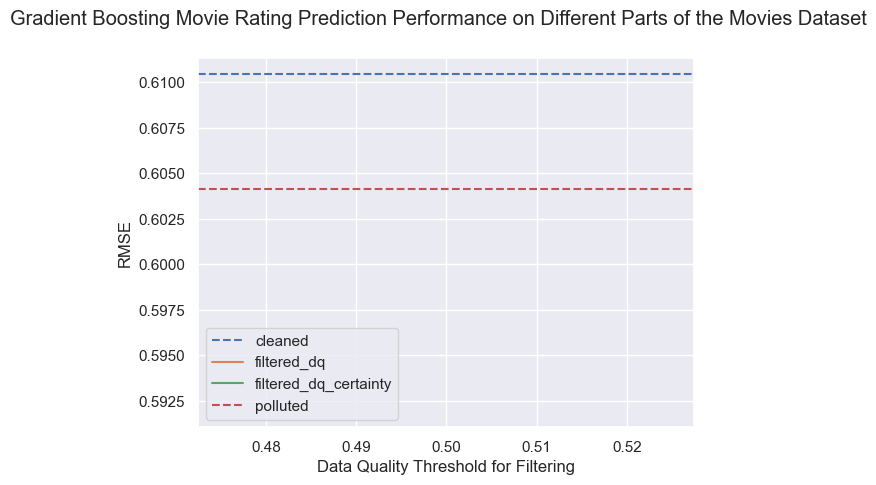

In [1]:
from downstream import plot_results, run_downstream_task

results_folder = run_downstream_task("movies")
plot_results(results_folder)

INFO:faiss.loader:Loading faiss.
INFO:faiss.loader:Successfully loaded faiss.


KeyError: None

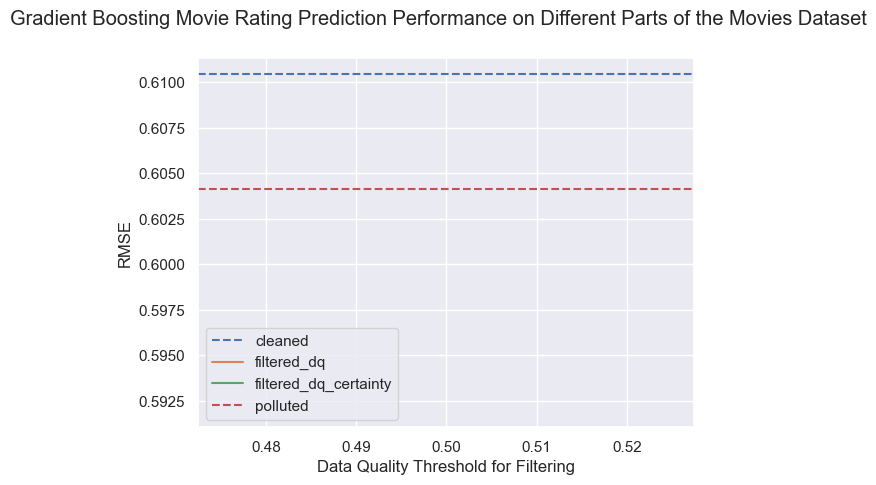

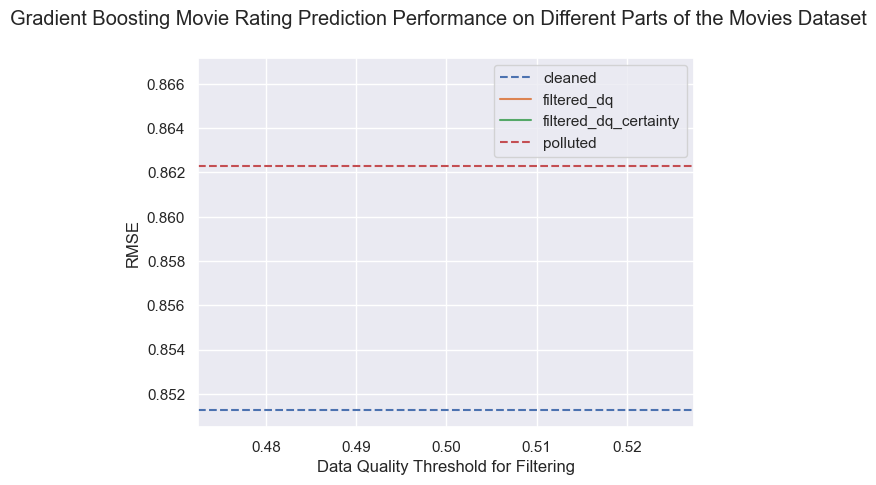

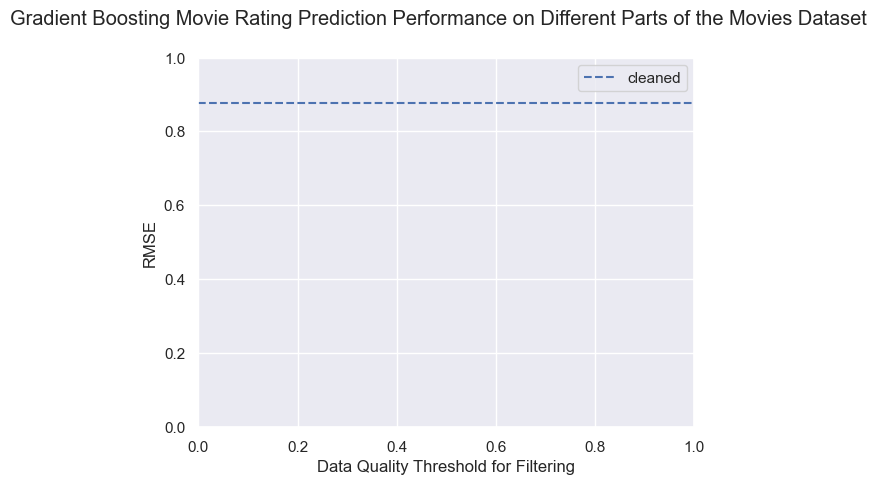

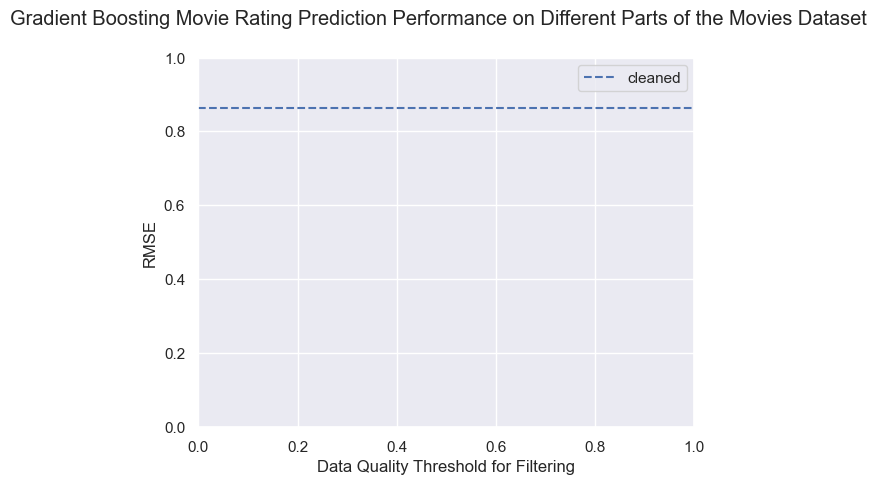

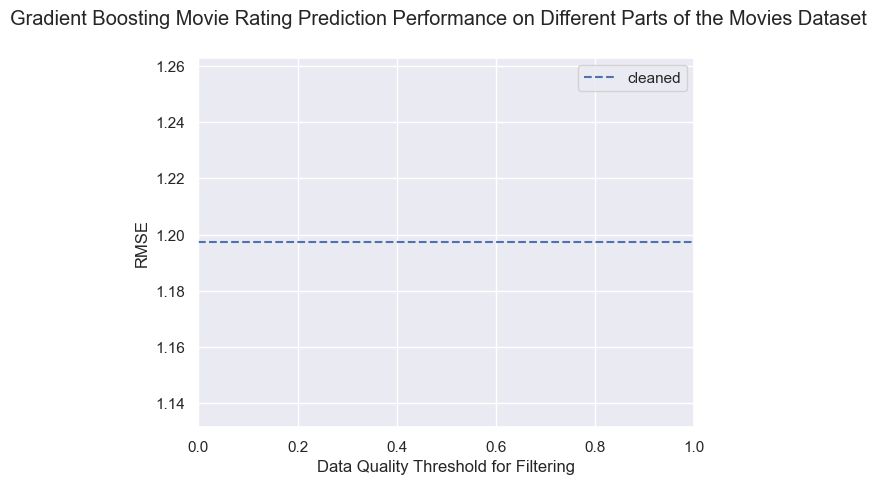

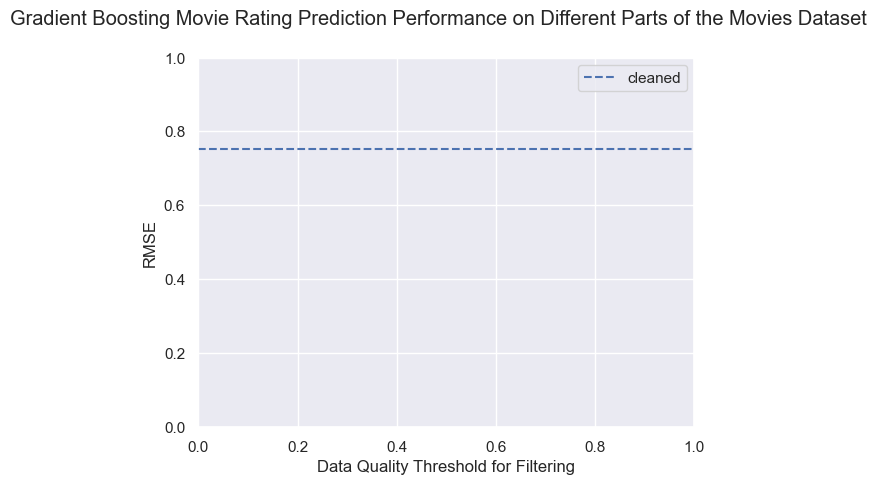

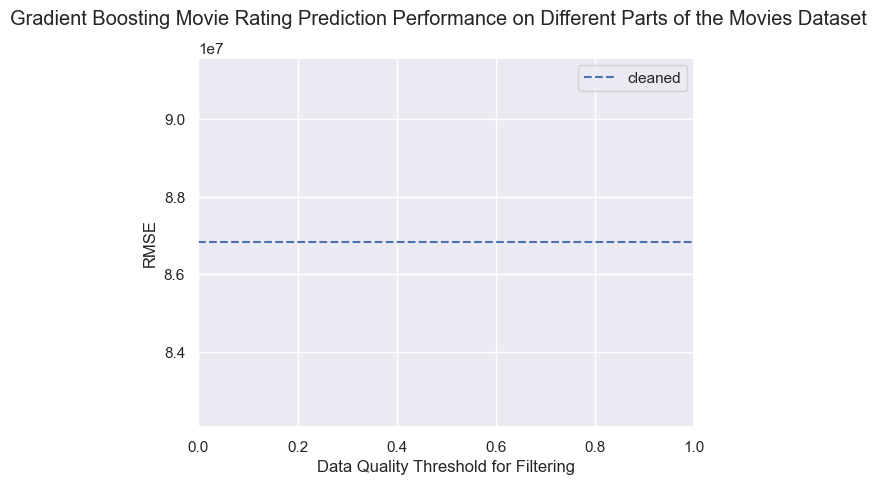

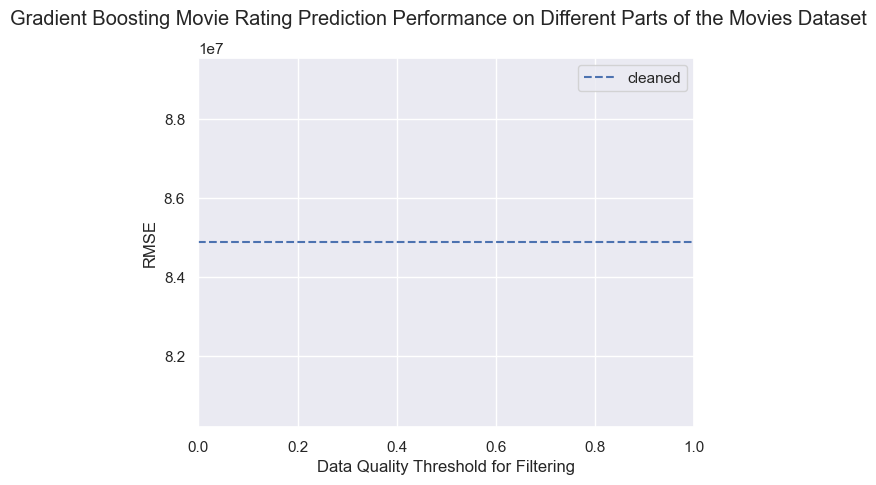

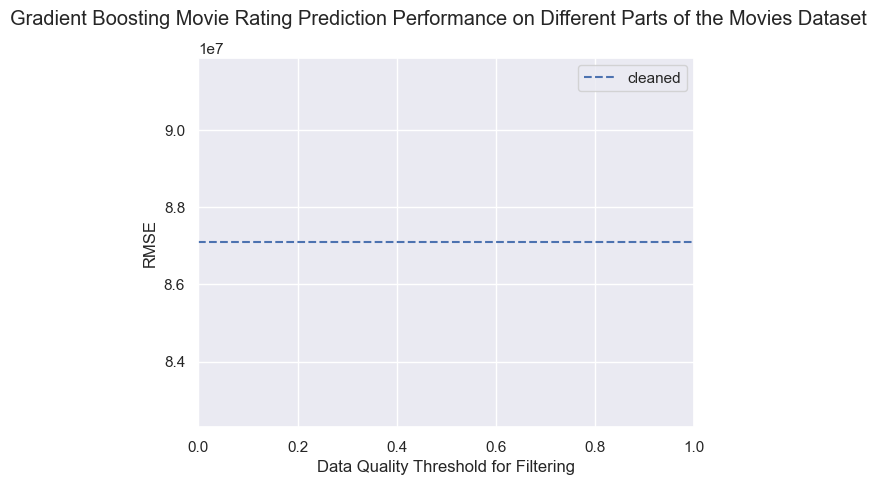

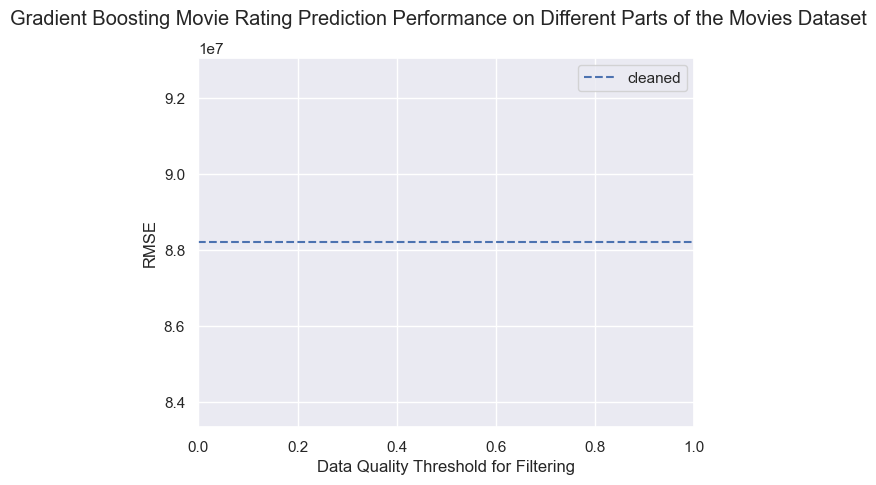

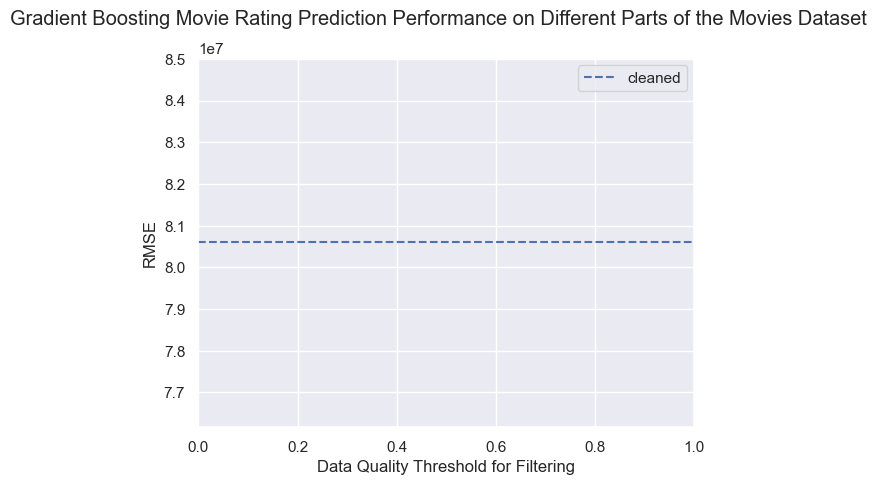

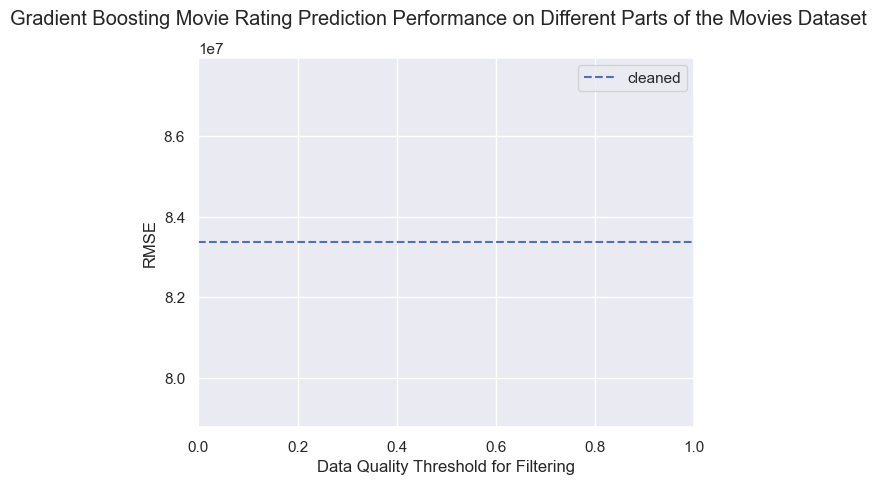

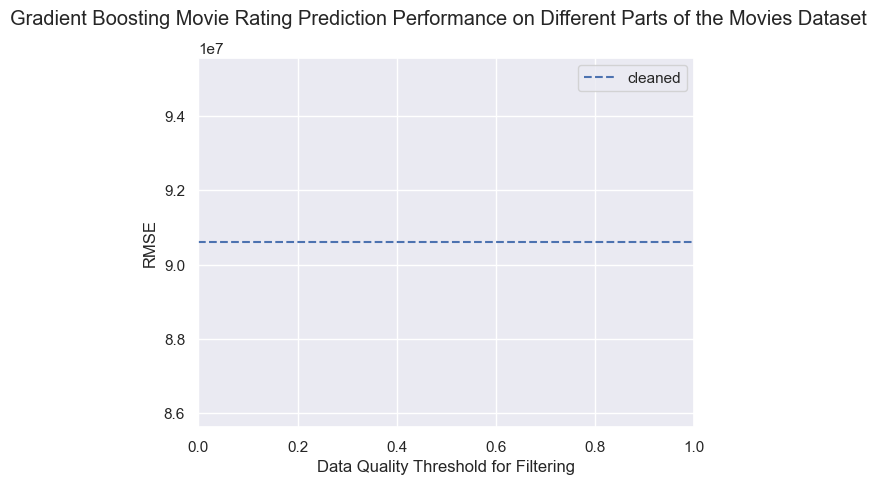

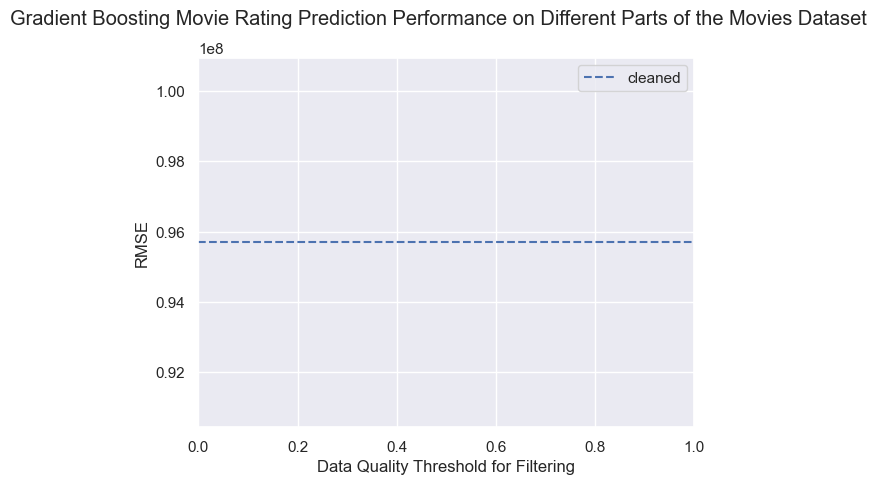

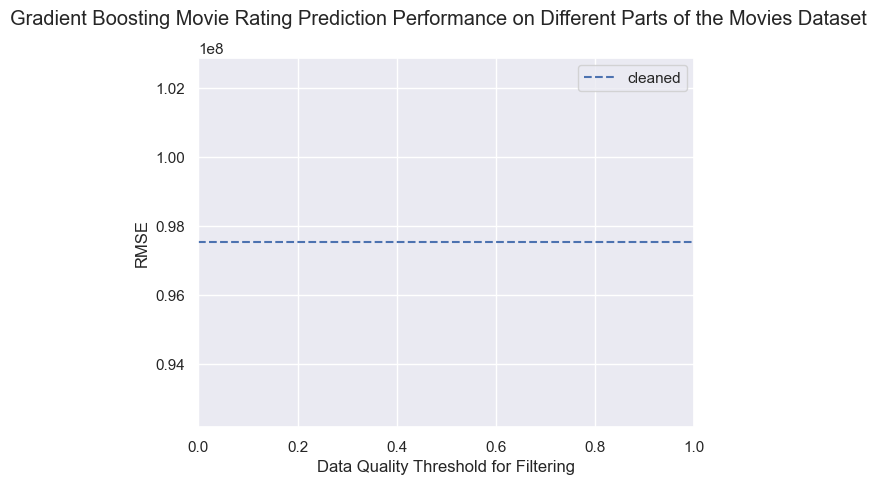

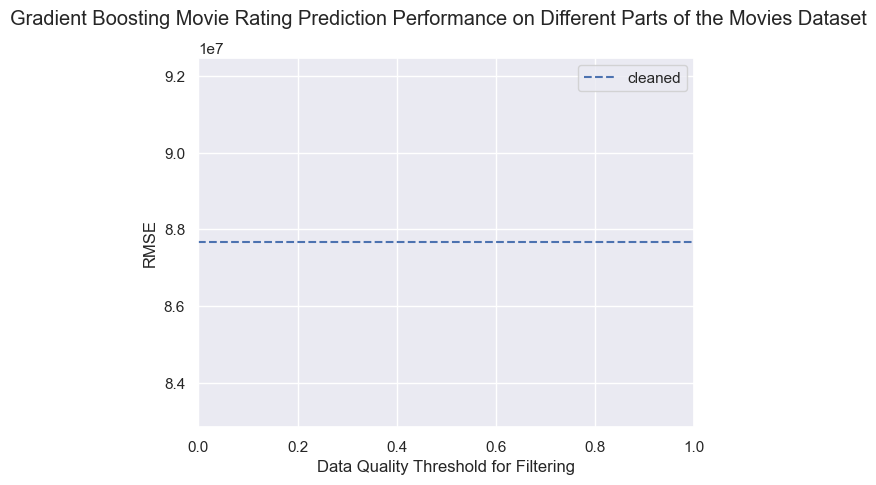

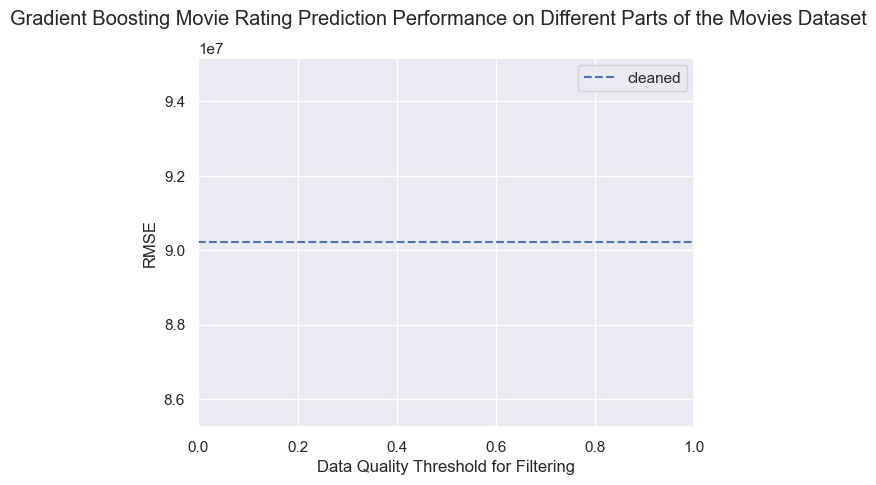

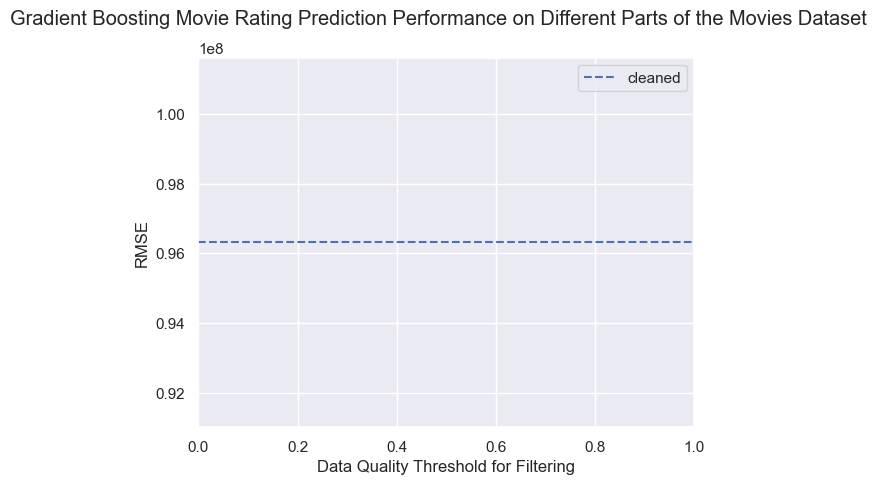

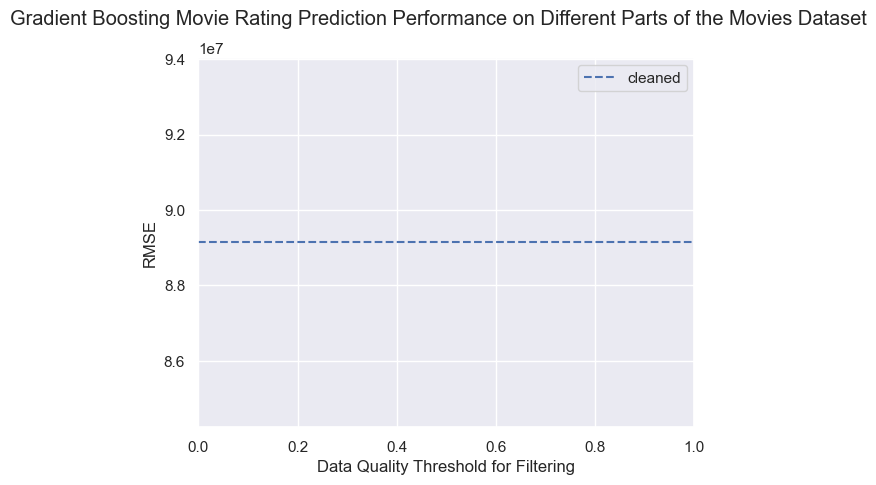

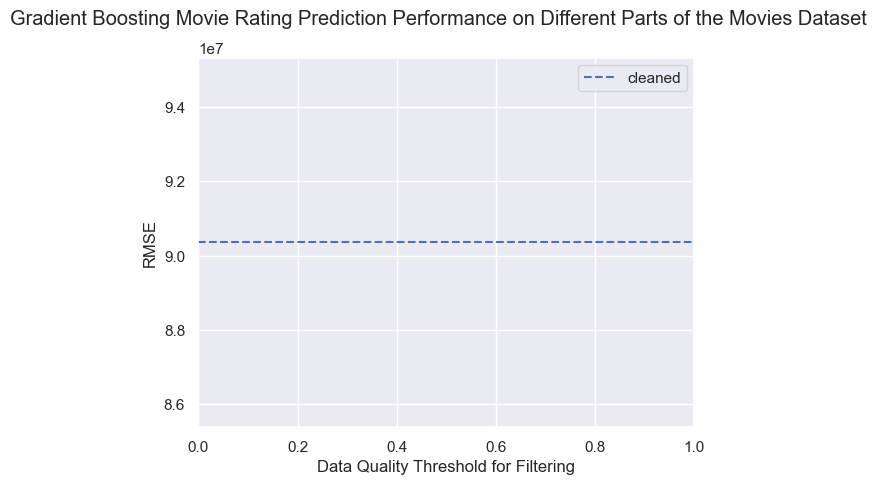

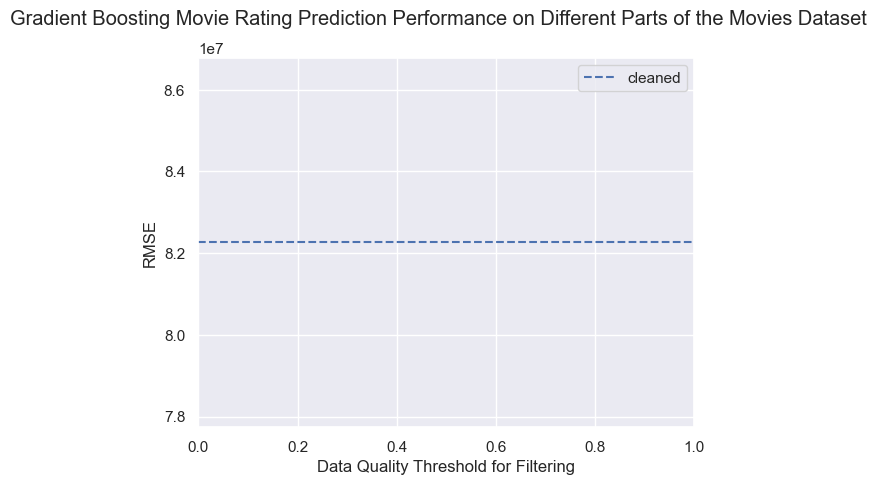

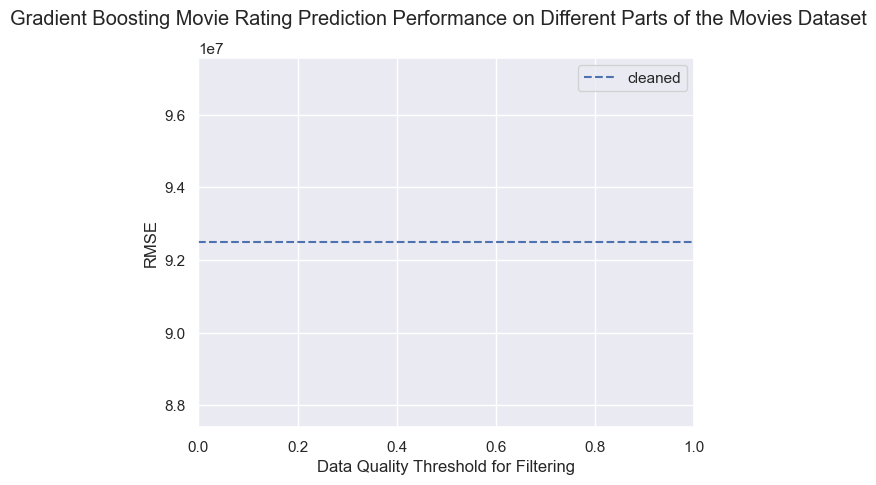

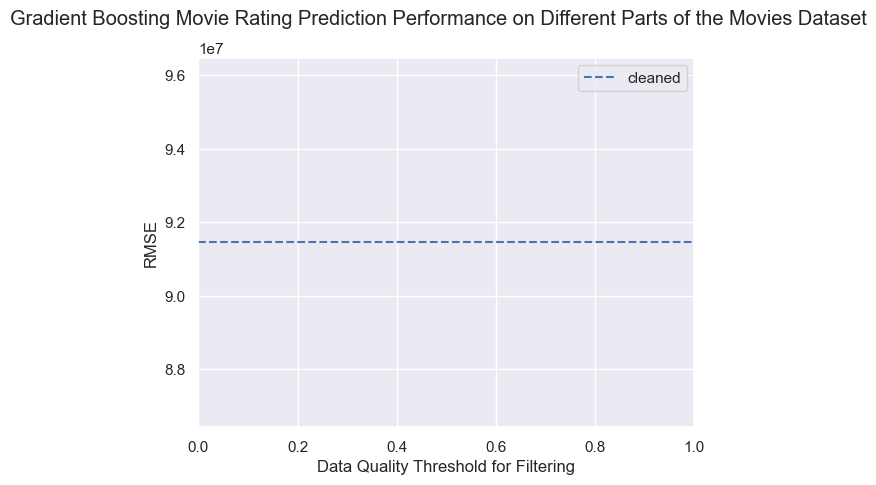

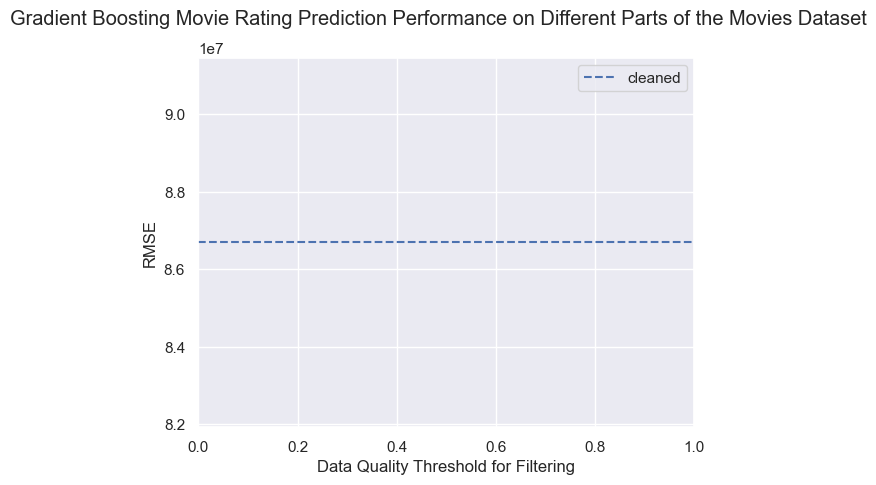

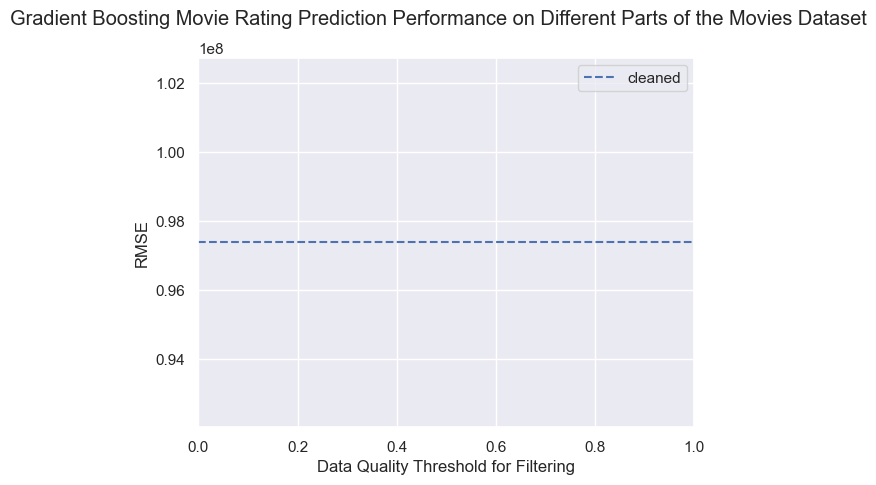

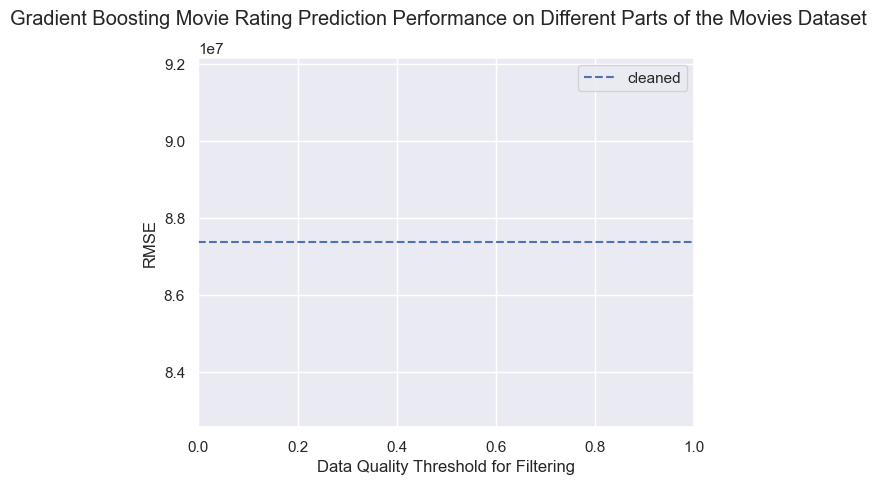

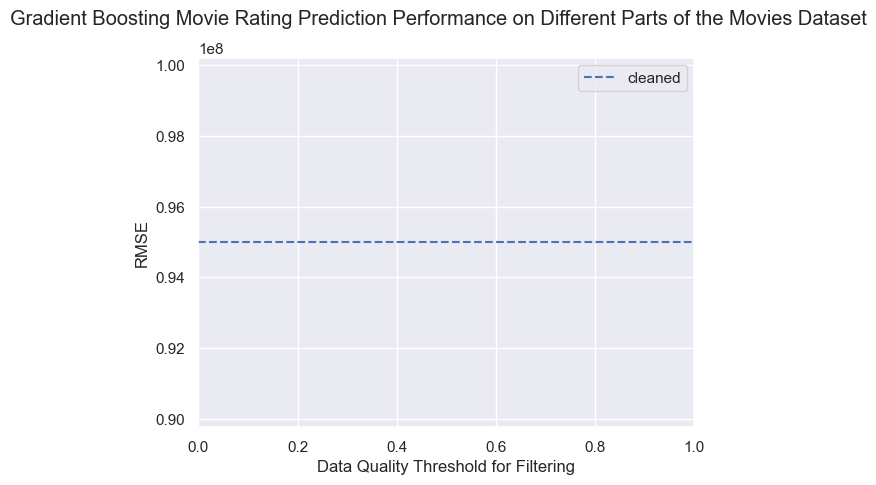

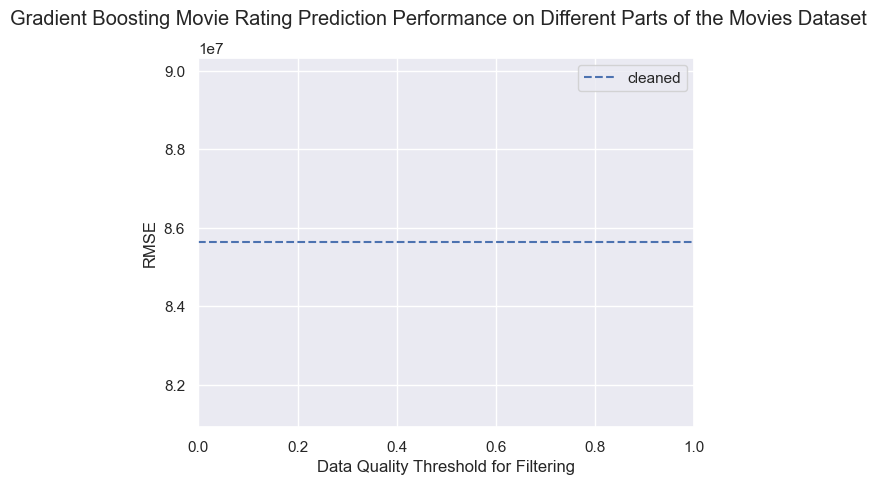

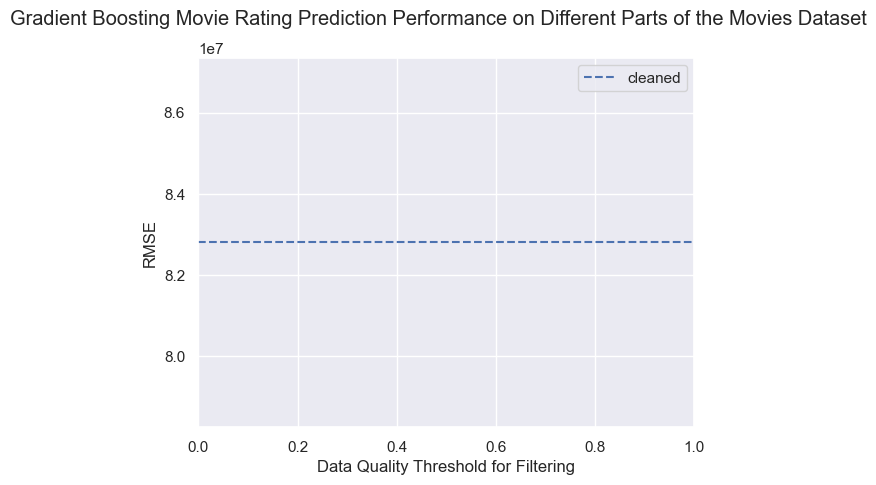

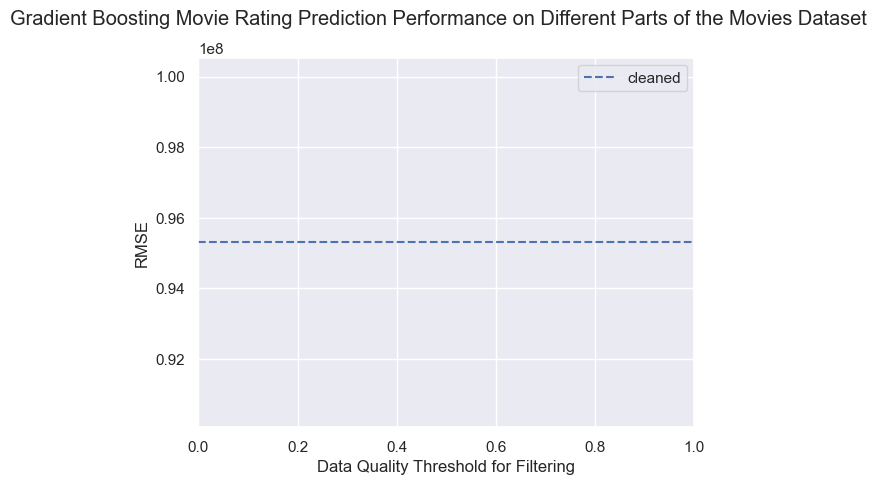

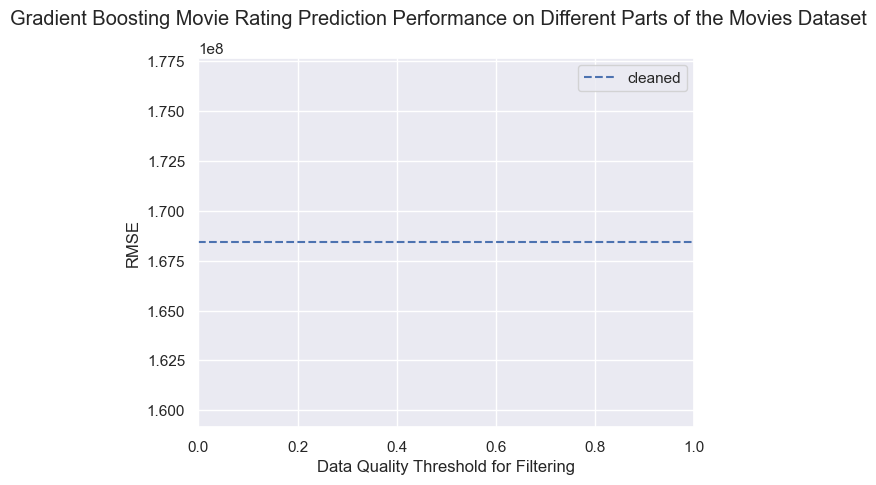

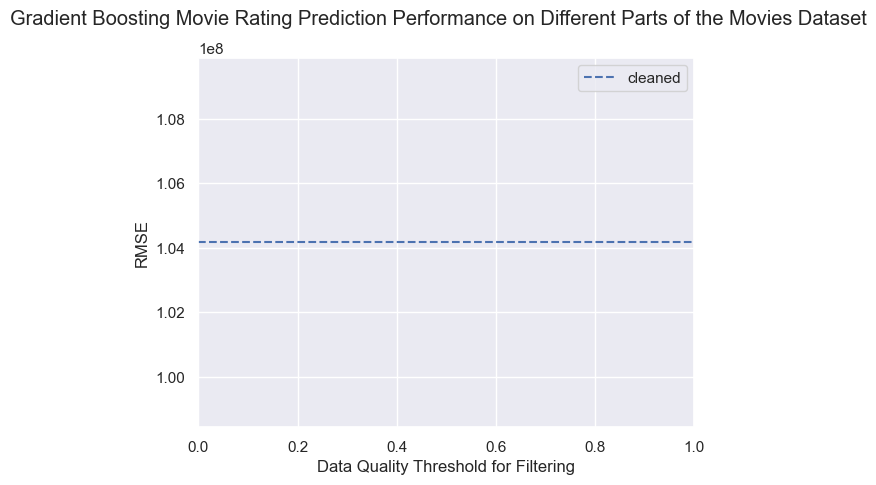

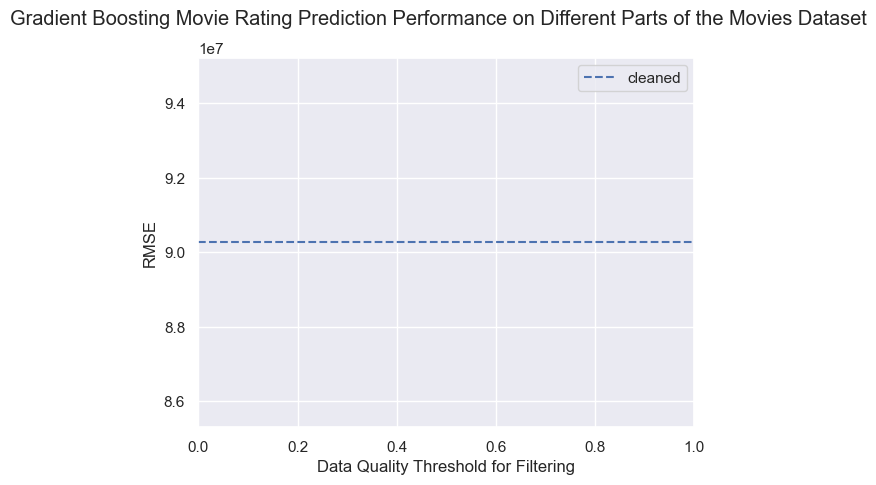

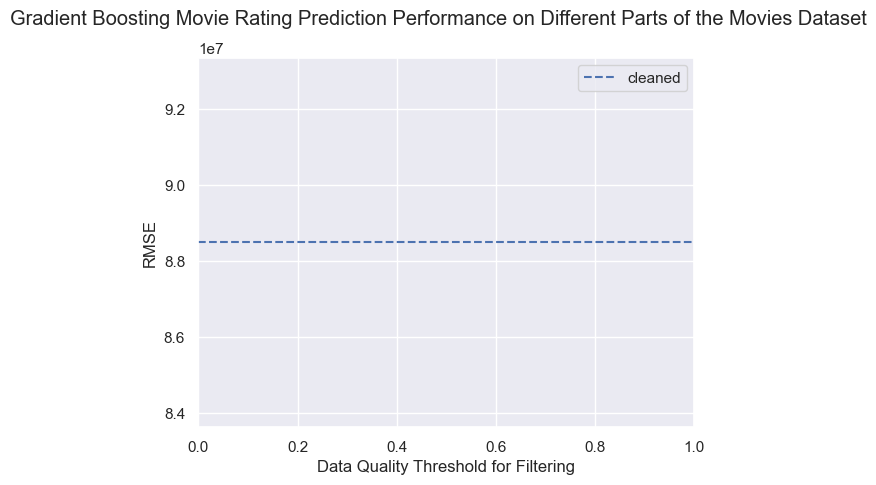

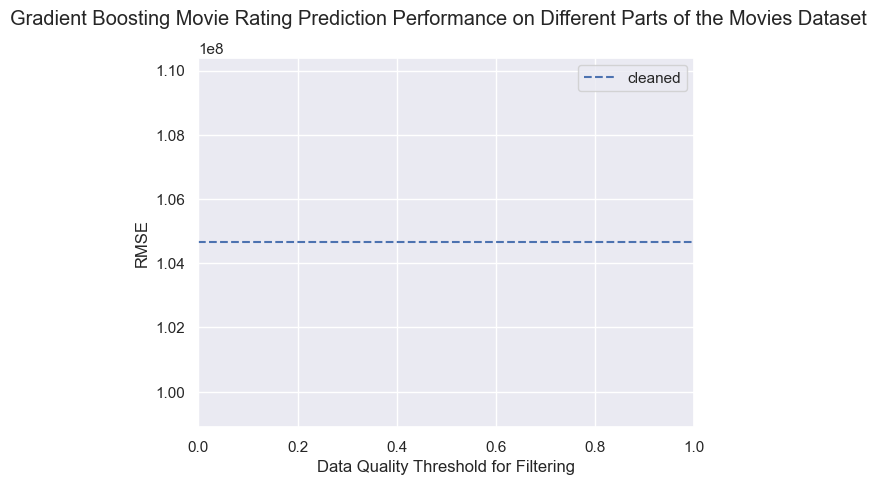

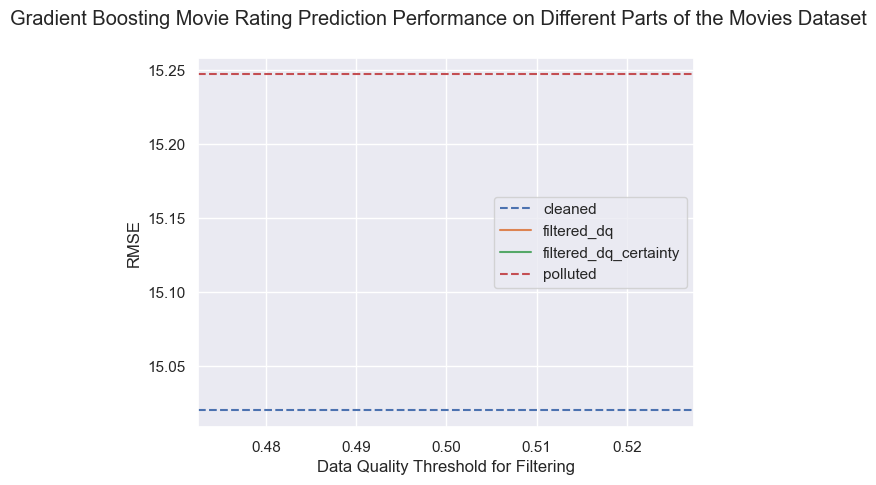

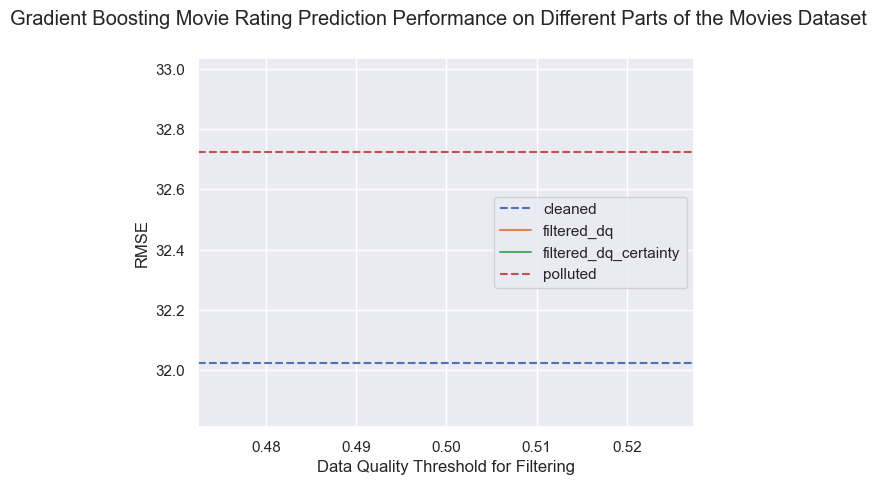

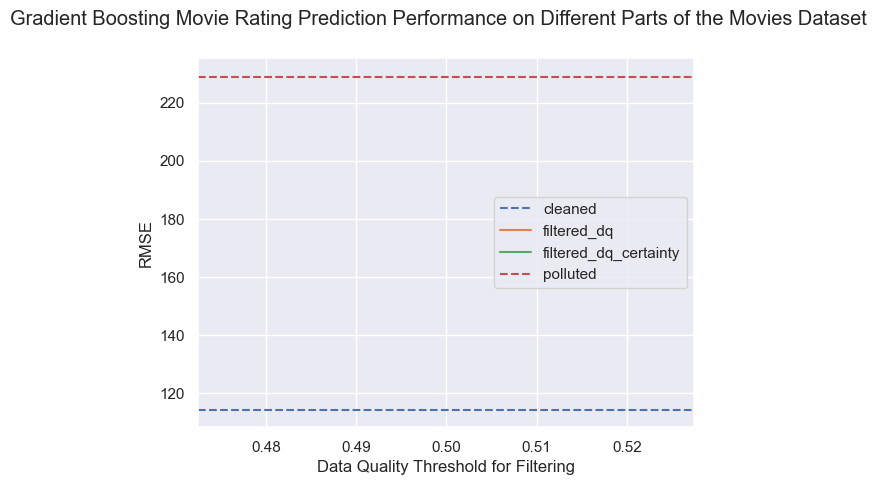

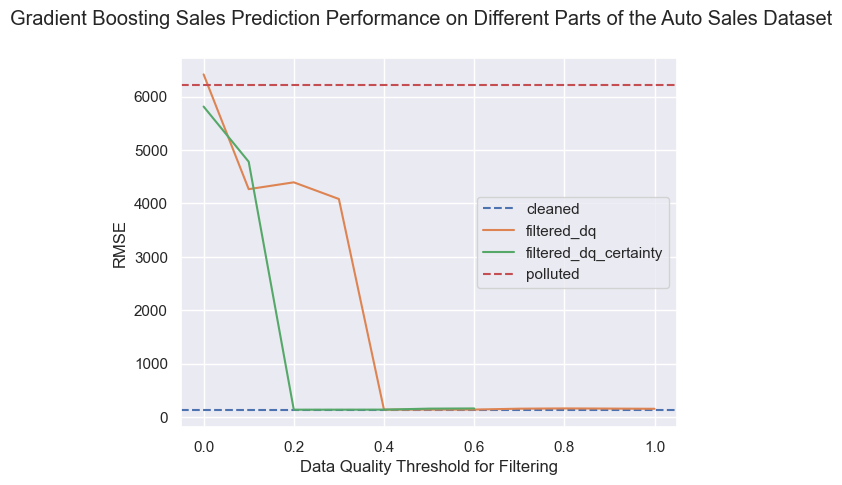

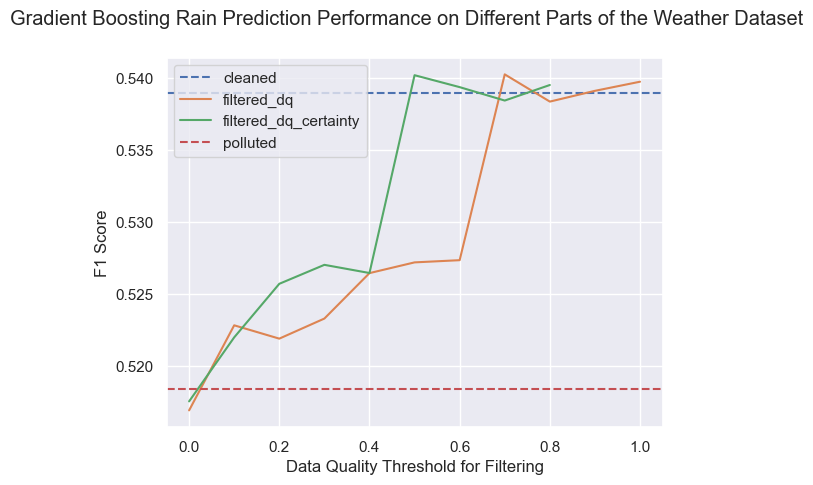

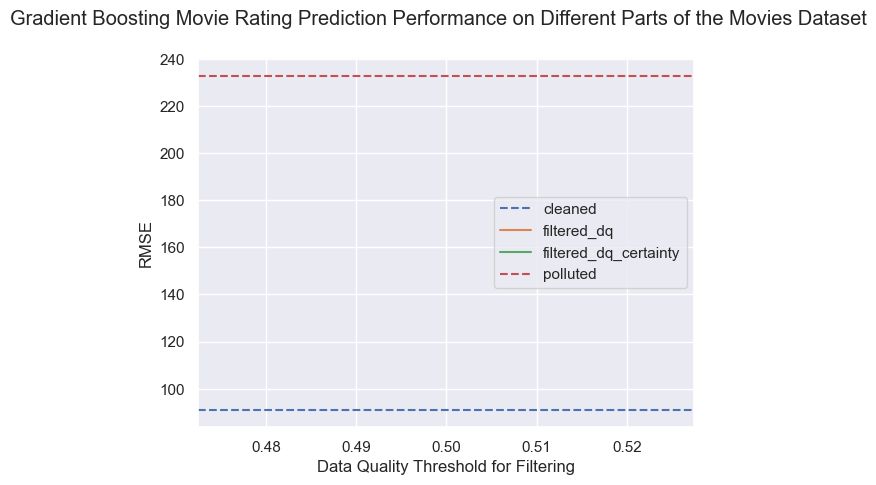

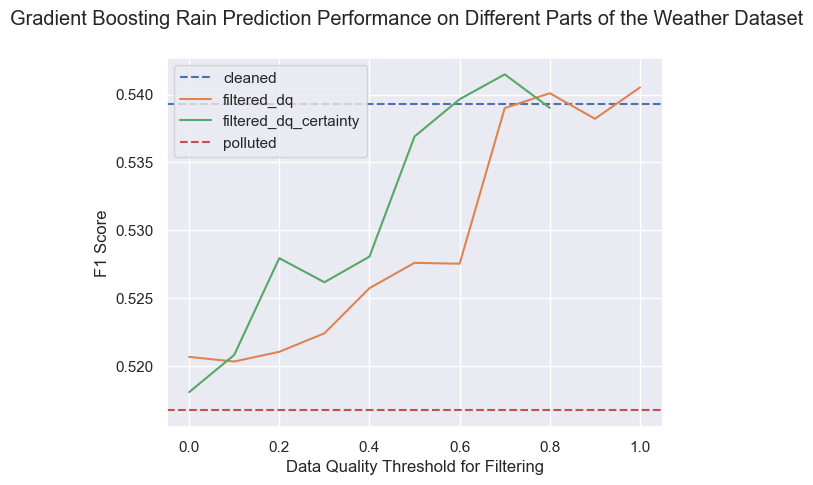

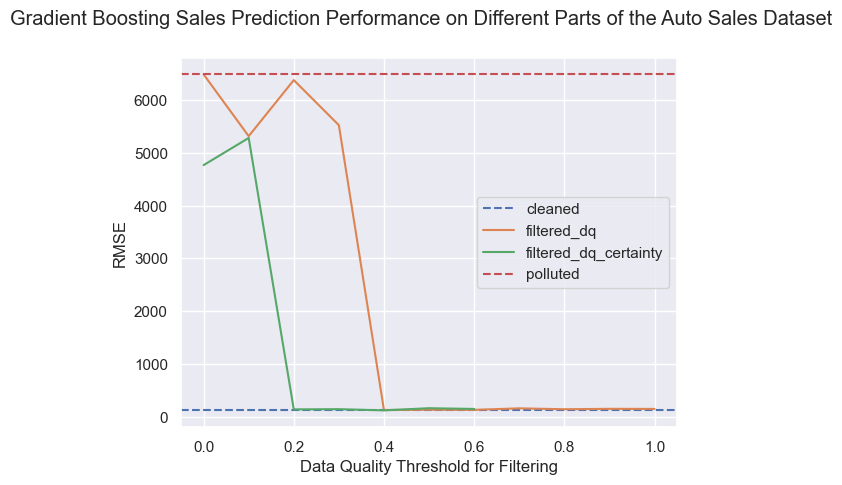

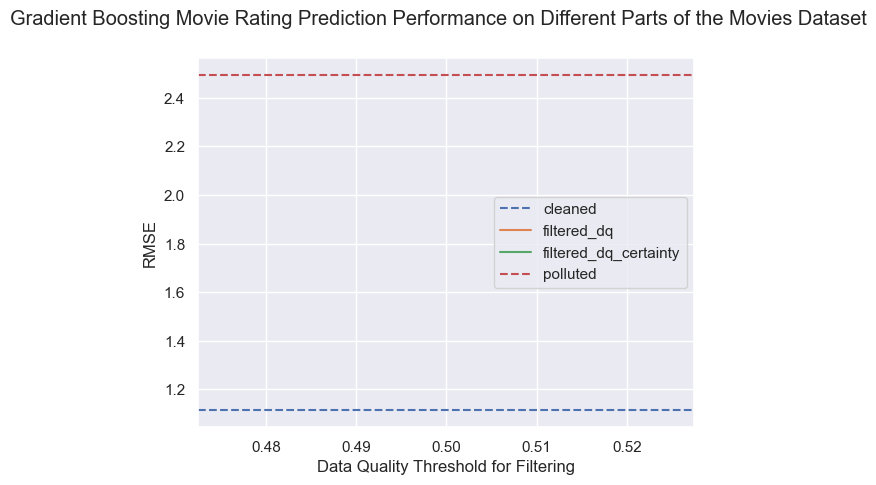

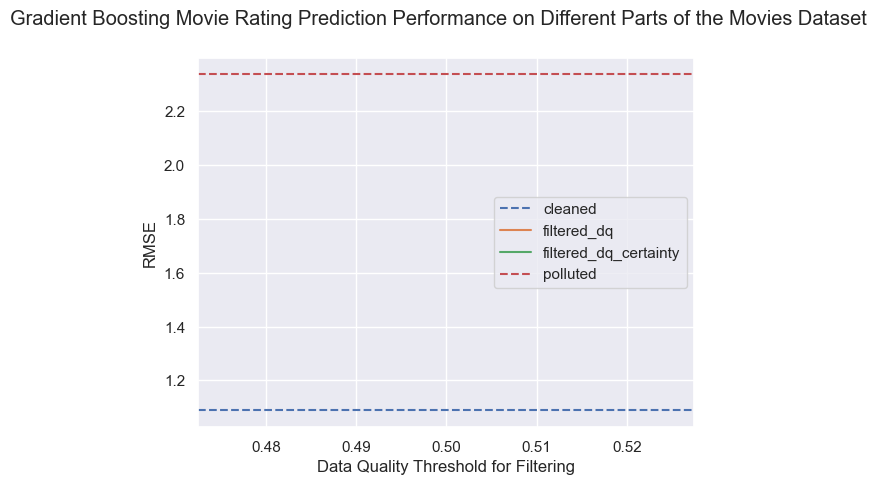

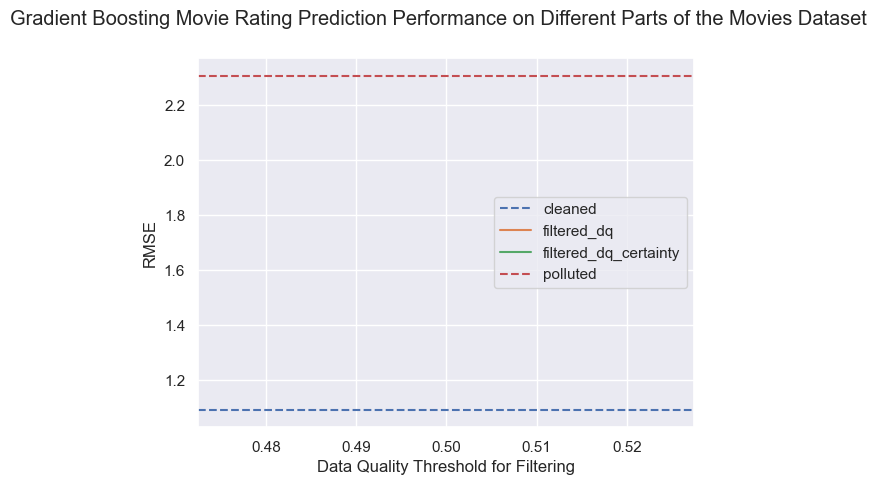

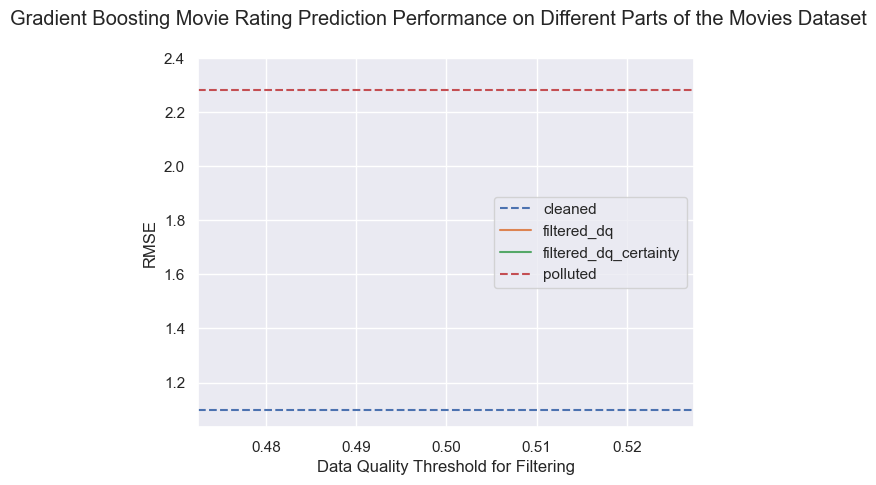

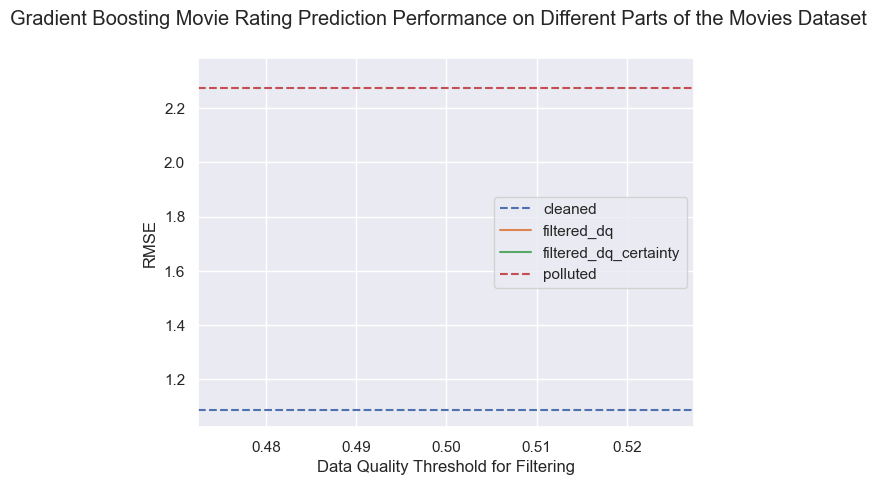

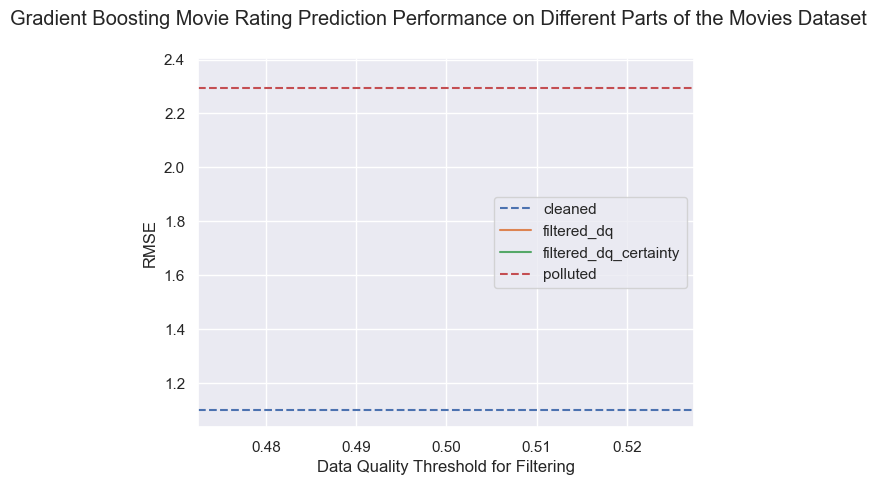

In [2]:
from pathlib import Path
from downstream import plot_results

results_path = Path("regression-results")
for folder in sorted(results_path.glob("*"), reverse=True):
    if not (folder / "results.csv").exists():
        continue
    plot_results(folder)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred))

0.8513393985342431
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     12340
         1.0       0.74      0.50      0.60      3488

    accuracy                           0.85     15828
   macro avg       0.80      0.73      0.75     15828
weighted avg       0.84      0.85      0.84     15828



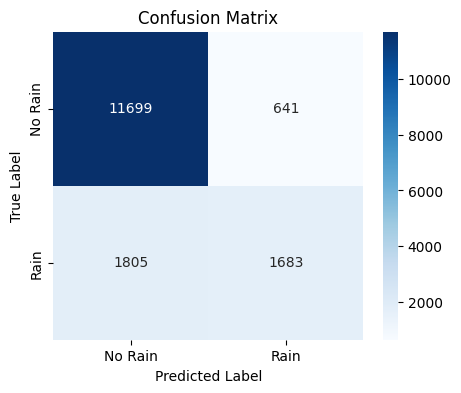

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 0, 'False Positive Rate')

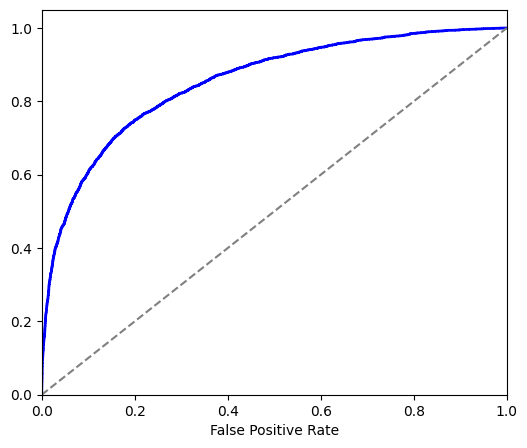

In [5]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")